In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

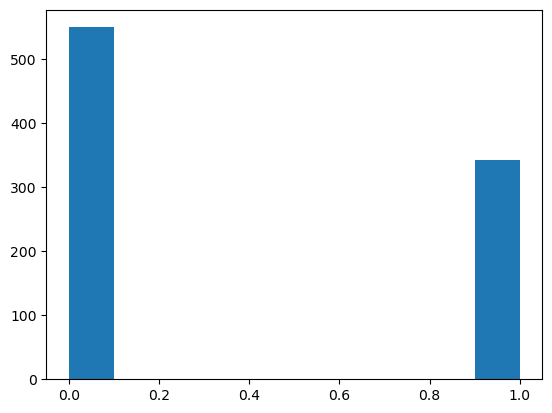

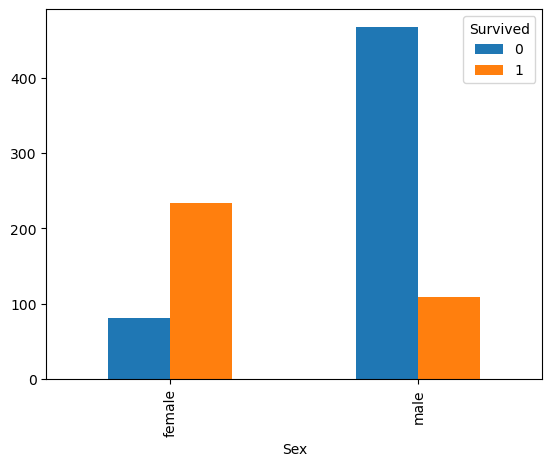

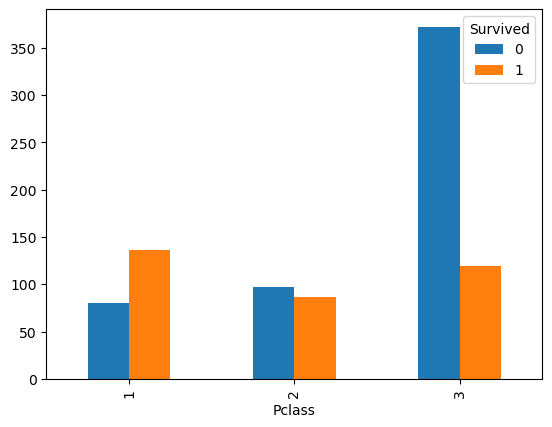

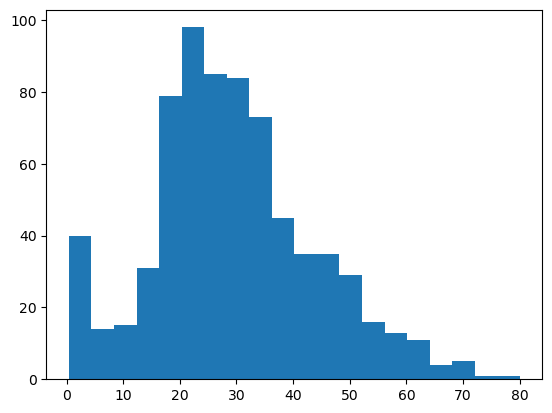

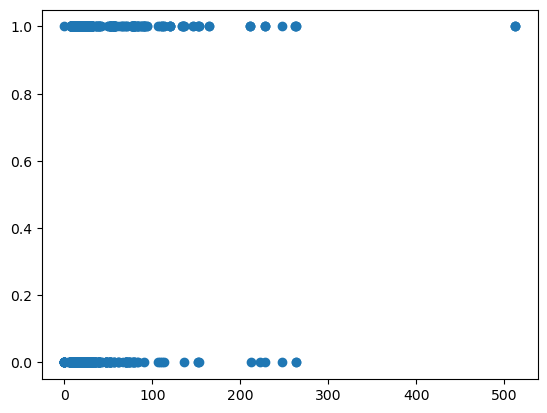

In [7]:
plt.hist(train['Survived'])
plt.show()

pd.crosstab(train['Sex'], train['Survived']).plot(kind='bar')
plt.show()

pd.crosstab(train['Pclass'], train['Survived']).plot(kind='bar')
plt.show()

plt.hist(train['Age'], bins=20)
plt.show()

plt.scatter(train['Fare'], train['Survived'])
plt.show()

In [8]:
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(test['Age'].median())

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

In [9]:
X = train[['Pclass','Sex','Age','SibSp','Parch','Fare']].values
y = train['Survived'].values

X_test = test[['Pclass','Sex','Age','SibSp','Parch','Fare']].values

In [10]:
mean = X.mean(axis=0)
std = X.std(axis=0)

X = (X - mean) / std
X_test = (X_test - mean) / std

X = np.c_[np.ones(X.shape[0]), X]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient_descent(X, y, w, alpha, iterations):
    m = len(y)
    for _ in range(iterations):
        h = sigmoid(X @ w)
        gradient = (1/m) * (X.T @ (h - y))
        w -= alpha * gradient
    return w

In [12]:
w = np.zeros(X.shape[1])
w = gradient_descent(X, y, w, 0.01, 1000)

In [13]:
preds = sigmoid(X_test @ w)
preds = (preds >= 0.5).astype(int)

In [15]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": preds
})

submission.to_csv("submission1.csv", index=False)